# Tobit 之后：截断、两部模型与比例因变量

> 本讲义用于《金融数据分析与建模》课程。配套文件 `05_truncated_twopart_codes.ipynb` 用于生成 `./figs/` 中的配图和 `./data/limitdep_alt_sim.csv`。

Tobit 模型提供了一种处理删失型连续因变量的标准方法。但在金融和企业数据中，很多变量虽然看起来“受限”或“有很多 0”，其背后的数据生成机制却不一定是删失。若不区分观测机制，很容易把 Tobit 用到并不适合的场景中。

本章围绕一个问题展开：当 Tobit 不是最合适选择时，应该如何根据数据生成机制选择替代模型？重点讨论三类模型：

- Truncated regression：样本被截断，部分样本根本没有进入数据；
- Two-part model：是否发生和发生多少由两个过程决定；
- Fractional response model：因变量是位于 $[0,1]$ 的比例变量。

本章主案例是企业银行贷款金额。企业贷款金额有大量 0，但这些 0 通常不是删失结果，而是企业没有获得贷款或没有借款的真实状态。此时，更自然的建模方式是先解释企业是否借款，再解释借款企业的贷款规模。


## 从模型地图开始

受限因变量模型的选择，关键不在于因变量是否有很多 0，而在于这些 0、边界值或缺失值是如何产生的。

![受限因变量模型选择地图](./figs/limit_dep_alt_fig01_model_map.png)

可以从以下几个问题出发：

- 样本是否全部进入数据？
- 因变量是否被完整观测？
- 0 是真实经济选择，还是边界外取值被合并后的结果？
- 是否参与和参与后的强度是否由同一机制决定？
- 结果变量是连续变量、比例变量，还是计数变量？

::: {.callout-important}
### 避坑指南：不要把“很多 0”自动等同于 Tobit

Tobit 适合的是“潜在连续变量被删失”的情形。如果 0 本身就是一个真实选择结果，例如企业没有借款、没有捐赠、没有申请专利，那么 Two-part model 往往更自然。若未选择样本中的结果变量根本不可观测，则问题更接近 Heckman selection。
:::


## 贷款金额案例：为什么不是 Tobit

考虑一个公司金融问题：哪些企业能够获得银行贷款？在获得贷款后，企业的贷款金额由哪些因素决定？

设企业 $i$ 的银行贷款金额为 $loan_i$。在数据中，经常可以看到大量企业满足：

$$
loan_i=0
$$

这可能来自两类完全不同的机制。

第一类机制是删失。假设存在一个潜在连续变量 $loan_i^*$，当 $loan_i^*\leq 0$ 时，数据库记录为 0；当 $loan_i^*>0$ 时，记录为 $loan_i=loan_i^*$。这是 Tobit 的思路。

第二类机制是两阶段决策。企业先经历一个是否借款或是否获得贷款的过程；只有在 $borrow_i=1$ 时，才进入贷款金额决定过程：

$$
borrow_i =
\begin{cases}
1, & \text{firm } i \text{ obtains a bank loan}\\
0, & \text{otherwise}
\end{cases}
$$

$$
loan_i =
\begin{cases}
0, & borrow_i=0\\
loan_i^+, & borrow_i=1
\end{cases}
$$

在银行信贷场景中，第二种机制通常更贴近现实，原因在于：

- 企业是否获得贷款，取决于银行审批、企业抵押品、银企关系、地区银行网点密度、政策性金融服务窗口等因素；
- 获得贷款以后，贷款金额又取决于企业资金需求、项目规模、资产负债表约束和银行授信额度。

因此，贷款金额为 0 并不一定表示潜在贷款金额被“压到 0”，而可能表示企业没有进入正值贷款金额的决定阶段。


## 数据生成机制：企业是否借款与借款规模

本章的主案例采用如下 two-part 数据生成过程。

第一部分是是否借款：

$$
borrow_i^*
=
z_i'\gamma
+
v_i
$$

$$
borrow_i =
\begin{cases}
1, & borrow_i^*>0\\
0, & borrow_i^*\leq 0
\end{cases}
$$

第二部分是在借款企业中的贷款金额：

$$
\log(loan_i)
=
x_i'\beta
+
u_i,\quad borrow_i=1
$$

最终观测到的贷款金额为：

$$
loan_i =
\begin{cases}
0, & borrow_i=0\\
\exp(x_i'\beta+u_i), & borrow_i=1
\end{cases}
$$

这里 $z_i$ 和 $x_i$ 不一定完全相同。影响企业是否借款的变量，可能包括抵押品、本地银行服务可得性、政银企对接窗口等；影响贷款金额的变量，则更侧重企业规模、资产负债率、盈利能力、现金持有和抵押品价值。

![贷款金额分布](./figs/limit_dep_alt_fig02_loan_amount_distribution.png)

![Two-part 机制](./figs/limit_dep_alt_fig03_twopart_mechanism.png)


In [2]:
# ============================================================
# 导入包与读取模拟数据
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 中文字体设置
# ------------------------------------------------------------
# 说明：
# 1. Windows 本地优先使用 SimHei，避免中文乱码；
# 2. macOS / Linux 自动寻找可用中文字体；
# 3. 本 notebook 在服务器环境下会自动使用 Noto Sans CJK JP，
#    该字体可以正常显示中文。
import platform
import matplotlib.font_manager as fm

def set_chinese_font():
    if platform.system() == "Windows":
        candidates = ["SimHei", "Microsoft YaHei", "SimSun"]
    elif platform.system() == "Darwin":
        candidates = ["PingFang SC", "Heiti SC", "Songti SC", "Arial Unicode MS"]
    else:
        candidates = [
            "Noto Sans CJK SC",
            "Noto Sans CJK JP",
            "Noto Sans CJK TC",
            "WenQuanYi Micro Hei",
            "Microsoft YaHei",
            "SimHei",
            "Arial Unicode MS",
        ]

    available_fonts = {font.name for font in fm.fontManager.ttflist}
    for font_name in candidates:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [font_name]
            plt.rcParams["axes.unicode_minus"] = False
            return font_name

    # 若没有找到中文字体，则退回 DejaVu Sans；此时英文和负号正常，但中文可能仍无法显示
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return "DejaVu Sans"

FONT_FAMILY = set_chinese_font()
print(f"当前使用字体: {FONT_FAMILY}")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)



当前使用字体: SimHei


In [3]:
# 数据概况
# 需要先运行 05_truncated_twopart_codes.ipynb，生成该数据文件
df = pd.read_csv("./data/limitdep_alt_sim.csv")
print(df.shape)

key_vars = ["borrow", "loan_amt", "size", "collateral", "bankbranch"]
df[key_vars].head().round(3)


(3000, 18)


,borrow,loan_amt,size,collateral,bankbranch
0,1,30.226,0.988,0.413,0.362
1,1,29.547,0.866,0.978,-0.752
2,1,20.849,0.662,0.518,-1.277
3,0,0.000,-0.147,0.599,-1.711
4,1,8.961,-0.258,0.391,0.466


In [4]:
# ============================================================
# 贷款金额变量的基本描述
# ============================================================

desc = pd.DataFrame({
    "统计量": [
        "样本量",
        "有贷款企业数量",
        "有贷款企业比例",
        "贷款金额 (均值)",
        "贷款金额 (中位数)",
        "贷款金额 (均值, 仅正值)",
        "贷款金额 (中位数, 仅正值)",
    ],
    "数值": [
        len(df),
        int(df["borrow"].sum()),
        df["borrow"].mean(),
        df["loan_amt"].mean(),
        df["loan_amt"].median(),
        df.loc[df["borrow"] == 1, "loan_amt"].mean(),
        df.loc[df["borrow"] == 1, "loan_amt"].median(),
    ]
}).round(3)

desc


,统计量,数值
0,样本量,3000.000
1,有贷款企业数量,1470.000
2,有贷款企业比例,0.490
3,贷款金额 (均值),10.022
4,贷款金额 (中位数),0.000
5,"贷款金额 (均值, 仅正值)",20.454
6,"贷款金额 (中位数, 仅正值)",14.869


In [4]:
# ============================================================
# 借款企业与未借款企业的特征对比
# ============================================================

compare_vars = ["size", "cash", "lev", "profit", "collateral", "bankbranch", "policy_window"]

compare_table = (
    df.groupby("borrow")[compare_vars]
      .agg(["mean", "std"])
      .T
)

compare_table.columns = ["未借款企业", "借款企业"]
compare_table.round(3)


未借款企业   借款企业
size          mean -0.417  0.379
              std   0.926  0.918
cash          mean  0.276  0.299
              std   0.153  0.161
lev           mean  0.384  0.351
              std   0.180  0.177
profit        mean -0.125  0.124
              std   0.558  0.554
collateral    mean  0.366  0.535
              std   0.238  0.253
bankbranch    mean -0.225  0.218
              std   0.993  0.956
policy_window mean  0.388  0.565
              std   0.487  0.496

## Truncated regression：样本被截断

截断 (truncation) 和删失 (censoring) 是最容易混淆的两个概念。删失数据中，边界外样本仍然在数据中，只是因变量被记录为边界值；截断数据中，边界外样本根本没有进入数据。

![删失、截断与选择的观测机制对比](./figs/limit_dep_alt_fig04_censor_trunc_select.png)

设潜在结果变量为：

$$
y_i^*=x_i'\beta+u_i,\quad u_i\sim N(0,\sigma^2)
$$

如果只有满足 $y_i^*>c$ 的样本才进入数据，则观测到的是：

$$
y_i=y_i^*\quad \text{only if } y_i^*>c
$$

在这种情况下，普通 OLS 面临的问题不是把边界值当成普通连续值，而是样本本身已经经过筛选。正确的似然函数应当使用截断正态分布的密度：

$$
f(y_i\mid y_i>c,x_i)
=
\frac{
\frac{1}{\sigma}
\phi\left(
\frac{y_i-x_i'\beta}{\sigma}
\right)
}{
1-\Phi\left(
\frac{c-x_i'\beta}{\sigma}
\right)
}
,\quad y_i>c
$$

在金融数据中，截断回归适合处理“只有超过报告门槛的合同才进入样本”“只观察到资产规模超过某一门槛的企业”等问题。它和 Heckman selection 的区别在于：截断规则通常直接由结果变量本身或固定门槛决定，而 Heckman selection 由另一个选择方程决定。

::: {.callout-note}
### 概念辨析：截断不是正值样本 OLS

只保留 $y_i>0$ 的样本做 OLS，并不等于截断回归。截断回归明确使用 $y_i>c$ 这一进入样本条件来修正条件密度。若只是删掉边界外样本再回归，通常仍然会产生偏误。
:::


::: {.callout-note}
### Stata 对应命令：`truncreg`

```stata
*------------------------------------------------------------
* 读取模拟数据
*------------------------------------------------------------
import delimited "./data/limitdep_alt_sim.csv", clear

*------------------------------------------------------------
* 截断回归示例：
* contract_observed 只有在超过报告门槛时才可观测
* ll(1.25) 表示左截断点为 1.25
*------------------------------------------------------------
truncreg contract_observed size lev collateral, ///
    ll(1.25) vce(robust)

margins, dydx(size lev collateral)
```
:::


## Two-part model：是否发生与发生多少

Two-part model 将结果变量的生成过程拆成两个部分。

第一部分解释是否为正：

$$
P(loan_i>0\mid z_i)=F(z_i'\gamma)
$$

其中 $F(\cdot)$ 可以是标准正态分布函数 (Probit)，也可以是 Logistic 分布函数 (Logit)。

第二部分解释正值样本中的结果大小：

$$
E(loan_i\mid loan_i>0,x_i)=g(x_i'\beta)
$$

如果正值贷款金额明显右偏，常见做法是对正值部分取对数：

$$
\log(loan_i)=x_i'\beta+u_i,\quad loan_i>0
$$

最终，非条件期望可以写成：

$$
E(loan_i\mid x_i,z_i)
=
P(loan_i>0\mid z_i)
\times
E(loan_i\mid loan_i>0,x_i)
$$

这就是 Two-part model 的核心。它允许“是否借款”和“借款多少”由不同机制决定，也允许两部分使用不同解释变量。

::: {.callout-important}
### 避坑指南：Two-part model 不等于 Heckman

Two-part model 通常把 0 看作真实结果，第一部分解释是否为正，第二部分解释正值大小。Heckman selection 则处理结果变量只在被选择样本中可观测的问题。如果未借款企业的贷款金额可以合理记为 0，问题更接近 Two-part；如果研究的是贷款利率，未借款企业没有贷款利率，问题更接近 Heckman。
:::


In [13]:
# ============================================================
# Two-part model：第一部分，是否借款
# ============================================================

# 第一部分变量：解释企业是否获得银行贷款
first_vars = ["size", "cash", "lev", "profit", "collateral", "bankbranch", "policy_window"]

Z = sm.add_constant(df[first_vars])
probit_model = sm.Probit(df["borrow"], Z)
probit_res = probit_model.fit(disp=False)

print(probit_res.summary())


                          Probit Regression Results                           
Dep. Variable:                 borrow   No. Observations:                 3000
Model:                         Probit   Df Residuals:                     2992
Method:                           MLE   Df Model:                            7
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.2531
Time:                        10:33:32   Log-Likelihood:                -1552.6
converged:                       True   LL-Null:                       -2078.8
Covariance Type:            nonrobust   LLR p-value:                5.524e-223
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.4428      0.099     -4.476      0.000      -0.637      -0.249
size              0.5584      0.035     16.048      0.000       0.490       0.627
cash              0.7308      0.166     

In [16]:
# ============================================================
# Two-part model：第二部分，正值贷款金额
# ============================================================

# 第二部分变量：解释借款企业的贷款规模
second_vars = ["size", "cash", "lev", "profit", "collateral", "bankbranch"]

df_pos = df.loc[df["borrow"] == 1].copy()

X_pos = sm.add_constant(df_pos[second_vars])
log_amt_model = sm.OLS(df_pos["ln_loan_amt"], X_pos)
log_amt_res = log_amt_model.fit(cov_type="HC1")

print(log_amt_res.summary())


                            OLS Regression Results                            
Dep. Variable:            ln_loan_amt   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     276.0
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          2.34e-236
Time:                        10:34:55   Log-Likelihood:                -1201.1
No. Observations:                1470   AIC:                             2416.
Df Residuals:                    1463   BIC:                             2453.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2602      0.054     41.815      0.0

In [18]:
# ============================================================
# 对比：直接对全部样本做 OLS，以及只在正值样本上做 OLS
# ============================================================

X_all = sm.add_constant(df[second_vars])

ols_all = sm.OLS(df["loan_amt"], X_all).fit(cov_type="HC1")
ols_pos_level = sm.OLS(df_pos["loan_amt"], X_pos).fit(cov_type="HC1")

table = summary_col(
    [ols_all, probit_res, log_amt_res, ols_pos_level],
    model_names=["OLS 全样本", "Probit 借款", "Log OLS 正值", "OLS 正值"],
    stars=True,
    float_format="%0.2f",
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
    }
)

print(table)



               OLS 全样本  Probit 借款 Log OLS 正值  OLS 正值 
-----------------------------------------------------
const          7.55***  -0.44***  2.26***    12.21***
               (0.81)   (0.10)    (0.05)     (1.21)  
size           7.56***  0.56***   0.56***    11.17***
               (0.40)   (0.03)    (0.02)     (0.64)  
cash           2.88*    0.73***   0.13       0.47    
               (1.50)   (0.17)    (0.09)     (2.24)  
lev            -6.49*** -0.91***  -0.30***   -6.41***
               (1.32)   (0.15)    (0.08)     (2.12)  
profit         4.82***  0.61***   0.22***    4.41*** 
               (0.47)   (0.05)    (0.03)     (0.77)  
collateral     9.50***  0.74***   0.46***    9.75*** 
               (1.08)   (0.12)    (0.07)     (1.57)  
bankbranch     2.21***  0.35***   0.12***    1.65*** 
               (0.24)   (0.03)    (0.02)     (0.41)  
policy_window           0.46***                      
                        (0.05)                       
R-squared      0.37        

上面的结果表有三个读法。

第一，`OLS 全样本` 把 0 和正值贷款金额混在一个线性模型中，容易掩盖“是否借款”和“借款多少”的机制差异。

第二，`Probit 借款` 解释的是企业进入正值贷款金额状态的概率。抵押品、本地银行服务可得性和政策窗口覆盖，通常更适合放在这一部分，因为它们更直接影响贷款可得性。

第三，`Log OLS 正值` 解释的是借款企业内部的贷款规模。此处的系数是正值样本上的条件关系，不应直接解释为对全样本贷款金额的平均影响。

非条件影响需要把两部分合并起来理解：一个变量既可能提高借款概率，也可能影响正值贷款金额。


In [ ]:
# ============================================================
# Two-part model：计算非条件预测 E(loan_amt | x)
# ============================================================

# 第一部分：预测借款概率
df["pred_prob_borrow"] = probit_res.predict(Z)

# 第二部分：预测正值贷款金额
# 若第二部分使用 log(loan_amt)，回到金额尺度时需要考虑 lognormal 修正项
sigma_hat = log_amt_res.resid.std(ddof=int(log_amt_res.df_model) + 1)

X_second_all = sm.add_constant(df[second_vars])
df["pred_amt_positive"] = np.exp(log_amt_res.predict(X_second_all) + 0.5 * sigma_hat**2)

# 非条件期望 = 借款概率 × 条件于借款时的贷款金额期望
df["pred_amt_uncond"] = df["pred_prob_borrow"] * df["pred_amt_positive"]

df[["loan_amt", "pred_prob_borrow", "pred_amt_positive", "pred_amt_uncond"]].describe().round(3)


,loan_amt,pred_prob_borrow,pred_amt_positive,pred_amt_uncond
count,3000.000,3000.000,3000.000,3000.000
mean,10.456,0.497,16.144,10.520
std,17.298,0.274,11.687,12.234
min,0.000,0.001,1.776,0.002
25%,0.000,0.266,8.210,2.205
50%,0.000,0.494,13.051,6.313
75%,14.947,0.729,20.493,14.268
max,191.694,0.999,103.259,103.139


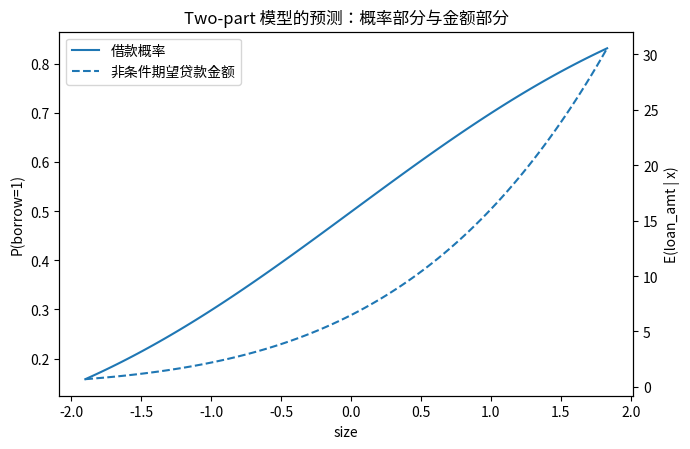

In [ ]:
# ============================================================
# 图形：企业规模与 Two-part 非条件预测
# ============================================================

size_grid = np.linspace(df["size"].quantile(0.03), df["size"].quantile(0.97), 100)
base = df[first_vars].mean()

grid_first = pd.DataFrame({
    "const": 1.0,
    "size": size_grid,
    "cash": base["cash"],
    "lev": base["lev"],
    "profit": base["profit"],
    "collateral": base["collateral"],
    "bankbranch": base["bankbranch"],
    "policy_window": base["policy_window"],
})

grid_second = grid_first.drop(columns=["policy_window"])

pred_prob = probit_res.predict(grid_first)
pred_positive_amt = np.exp(log_amt_res.predict(grid_second) + 0.5 * sigma_hat**2)
pred_uncond_amt = pred_prob * pred_positive_amt

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(size_grid, pred_prob, label="借款概率")
ax.set_xlabel("size")
ax.set_ylabel("P(borrow=1)")

ax2 = ax.twinx()
ax2.plot(size_grid, pred_uncond_amt, linestyle="--", label="非条件期望贷款金额")
ax2.set_ylabel("E(loan_amt | x)")

lines = ax.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc="upper left")

ax.set_title("Two-part 模型的预测：概率部分与金额部分")
plt.tight_layout()
plt.show()


::: {.callout-note}
### Stata 对应命令：手动估计 Two-part model

```stata
*------------------------------------------------------------
* 读取模拟数据
*------------------------------------------------------------
import delimited "./data/limitdep_alt_sim.csv", clear

*------------------------------------------------------------
* 第一部分：是否取得银行贷款
*------------------------------------------------------------
probit borrow size cash lev profit collateral bankbranch policy_window, ///
    vce(robust)

margins, dydx(size cash lev profit collateral bankbranch policy_window)

predict phat_borrow, pr

*------------------------------------------------------------
* 第二部分：正值贷款金额
*------------------------------------------------------------
regress ln_loan_amt size cash lev profit collateral bankbranch ///
    if borrow == 1, vce(robust)

predict xb_ln_amt if e(sample), xb

*------------------------------------------------------------
* 若要在金额尺度上预测，需要根据 lognormal 结构做额外处理。
* 实证论文中通常会同时报告第一部分和第二部分结果，
* 并根据研究问题进一步计算非条件预测。
*------------------------------------------------------------
```
:::


::: {.callout-note}
### Stata 扩展命令：`twopm`

`twopm` 是 Stata 中常用的 two-part model 用户命令，适合把第一部分和第二部分放在一个框架下估计。若本地尚未安装，可以先执行：

```stata
ssc install twopm, replace
```

示例命令如下：

```stata
twopm loan_amt size cash lev profit collateral bankbranch, ///
    firstpart(probit) ///
    secondpart(glm, family(gamma) link(log)) ///
    vce(robust)

margins, dydx(size cash lev profit collateral bankbranch)
```

`twopm` 的优点是语法紧凑，便于计算整体边际效应。若希望充分理解两部分模型的含义，仍建议先手动估计第一部分和第二部分。
:::


::: {.callout-tip}
### 提示词：生成 Two-part model 的 Python 代码

我正在分析一个 Two-part model。因变量是 `因变量名`，其中 0 表示没有发生该行为，正值表示发生后的强度。

- 第一部分使用 Probit 解释 `因变量名 > 0`，解释变量包括 `第一部分变量列表`；
- 第二部分在正值样本中估计 `log(因变量名)`，解释变量包括 `第二部分变量列表`。

请帮我生成 Python 代码，完成描述性统计、第一部分 Probit、第二部分 OLS、结果表整理、非条件预测和边际效应图。代码需要包含中文注释，并假定数据已经保存在 pandas DataFrame `df` 中。
:::

::: {.callout-tip}
### 提示词：生成 Two-part model 的 Stata 代码

我正在使用 Stata 估计 Two-part model。因变量是 `因变量名`，0 表示没有发生该行为，正值表示发生后的强度。

- 第一部分使用 Probit，第二部分在正值样本中估计 `log(因变量名)`。
- 请帮我生成手动两部分估计代码，并补充 `twopm` 的写法。代码需要使用 `///` 换行，并添加中文注释。
:::


## Hurdle model 与 zero-inflated count model

Two-part model 常用于连续正值变量。若结果变量是计数变量，例如企业专利数量、绿色专利数量、并购次数、违规处罚次数、分析师跟踪数量，则大量 0 的问题通常需要使用计数模型。

Hurdle model 的基本思想与 Two-part model 类似：

- 第一部分：是否跨过 0 这个门槛；
- 第二部分：在正值样本中，计数结果如何分布。

Zero-inflated model 则假设 0 来自两个来源：一部分是结构性 0，另一部分是计数过程自然产生的 0。

::: {.callout-note}
### 概念辨析：Hurdle 和 zero-inflated 的差别

Hurdle model 把 0 与正值严格分开，正值部分通常使用零截断计数分布。Zero-inflated model 允许 0 同时来自结构性 0 和普通计数过程。因此，二者都能处理“很多 0”，但背后的 DGP 不同。
:::


::: {.callout-note}
### Stata 对应命令：计数结果中的大量 0

```stata
*------------------------------------------------------------
* Poisson 基准模型
*------------------------------------------------------------
poisson green_patents size cash lev profit, ///
    vce(robust)

*------------------------------------------------------------
* 零膨胀 Poisson：inflate() 中放入解释结构性 0 的变量
*------------------------------------------------------------
zip green_patents size cash lev profit, ///
    inflate(size cash collateral bankbranch) ///
    vce(robust)

*------------------------------------------------------------
* 零膨胀负二项：适合过度离散更明显的计数数据
*------------------------------------------------------------
zinb green_patents size cash lev profit, ///
    inflate(size cash collateral bankbranch) ///
    vce(robust)
```
:::


## Fractional response model：比例因变量的自然边界

很多金融变量天然位于 $[0,1]$ 区间，例如：

- 现金持有率；
- 资产负债率；
- 机构投资者持股比例；
- 股权质押比例；
- 绿色贷款占比；
- 出口收入占比；
- ESG 披露得分标准化后的比例。

若因变量是比例变量，即使存在大量 0 或 1，也不必然适合 Tobit。Tobit 的逻辑是潜在连续变量被删失；fractional response model 则直接建模比例变量的条件均值：

$$
E(y_i\mid x_i)=G(x_i'\beta)
$$

其中 $G(\cdot)$ 通常取 logit 函数：

$$
G(x_i'\beta)
=
\frac{\exp(x_i'\beta)}{1+\exp(x_i'\beta)}
$$

这样可以保证预测值始终位于 $[0,1]$ 区间内。

![比例因变量与 fractional response](./figs/limit_dep_alt_fig05_fractional_response.png)


In [ ]:
# ============================================================
# Fractional response model：使用 GLM Binomial 拟合比例变量
# ============================================================

frac_vars = ["size", "cash", "lev", "profit", "bankbranch"]
X_frac = sm.add_constant(df[frac_vars])

# statsmodels 的 GLM Binomial 可用于 Papke-Wooldridge fractional logit 的条件均值估计
frac_model = sm.GLM(
    df["green_share"],
    X_frac,
    family=sm.families.Binomial()
)

frac_res = frac_model.fit(cov_type="HC1")
print(frac_res.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:            green_share   No. Observations:                 3000
Model:                            GLM   Df Residuals:                     2994
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1279.0
Date:                Tue, 28 Apr 2026   Deviance:                       559.81
Time:                        10:28:48   Pearson chi2:                     506.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.04841
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8579      0.048    -17.961      0.0

In [ ]:
# ============================================================
# Fractional response model：平均边际效应
# ============================================================

# 对 logit 均值函数而言，边际效应为 G(xb) * [1 - G(xb)] * beta_j
mu_hat = frac_res.predict(X_frac)
scale = mu_hat * (1 - mu_hat)

ame_frac = pd.DataFrame({
    "变量": frac_vars,
    "系数": frac_res.params[frac_vars].values,
    "平均边际效应": [np.mean(scale * frac_res.params[var]) for var in frac_vars]
})

ame_frac.round(4)


,变量,系数,平均边际效应
0,size,0.2985,0.0600
1,cash,0.4820,0.0970
2,lev,-0.4370,-0.0879
3,profit,0.3866,0.0778
4,bankbranch,0.3191,0.0642


::: {.callout-note}
### Stata 对应命令：`fracreg logit`

```stata
*------------------------------------------------------------
* Fractional logit：比例因变量位于 [0, 1]
*------------------------------------------------------------
fracreg logit green_share size cash lev profit bankbranch, ///
    vce(robust)

* 平均边际效应
margins, dydx(size cash lev profit bankbranch)

* 条件预测值
predict green_share_hat, mu
```
:::

::: {.callout-important}
### 避坑指南：比例变量不必然使用 Tobit

如果 0 和 1 是比例变量的自然边界，而不是潜在变量被删失后的记录值，fractional response model 往往比 Tobit 更贴合研究问题。此时，模型的目标是估计 $E(y_i\mid x_i)$，而不是恢复某个未观测的潜在连续变量。
:::


## 模型选择指南

可以按照以下顺序判断模型。

 1. **Step 1**: 判断结果变量类型。它是连续型、比例型，还是计数型？
 2. **Step 2**: 判断 0 或边界值的经济含义。它是真实选择，还是删失后的边界记录？
 3. **Step 3**: 判断样本是否完整进入数据。边界外样本是否仍然存在？
 4. **Step 4**: 判断是否参与和参与后的强度是否由同一机制决定。
 5. **Step 5**: 判断结果变量是否只在被选择样本中可观测。

| 数据特征 | 观测机制 | 更合适的模型 |
|---|---|---|
| 潜在连续变量被压到边界 | 删失 | Tobit |
| 边界外样本根本看不到 | 截断 | Truncated regression |
| 0 是真实选择，正值大小另由一套机制决定 | 两阶段决策 | Two-part model |
| 计数变量有大量 0 | 门槛或结构性 0 | Hurdle / zero-inflated count model |
| 比例变量位于 $[0,1]$ | 条件均值受限 | Fractional response |
| 结果变量只在被选择样本中可观测 | 样本选择 | Heckman selection |

::: {.callout-note}
### 与下一章的衔接

本章的贷款金额案例中，未借款企业的贷款金额可以合理记为 0，因此 Two-part model 是自然选择。下一章研究贷款利率时，未借款企业没有贷款利率，结果变量并不是 0，而是不可观测。这时，问题转化为样本选择偏误，需要使用 Heckman selection model。
:::


## 附录：Python 中的截断回归简易实现

Python 中没有像 Stata `truncreg` 那样统一、常用的基础命令。为便于理解截断回归的估计逻辑，下面给出一个左截断正态回归的简易 MLE 函数。正式论文中若使用截断回归，建议优先用 Stata 的 `truncreg` 做结果核对。

设左截断点为 $c$，只观察到 $y_i>c$ 的样本。对数似然为：

$$
\ell(\beta,\sigma)
=
\sum_i
\left[
-\log\sigma
+
\log\phi\left(\frac{y_i-x_i'\beta}{\sigma}\right)
-
\log\left\{
1-\Phi\left(\frac{c-x_i'\beta}{\sigma}\right)
\right\}
\right]
$$


In [ ]:
# ============================================================
# 左截断正态回归：简易 MLE 实现
# ============================================================

def fit_left_truncated_normal(y, X, left):
    '''
    使用极大似然估计左截断正态回归。

    参数
    ----
    y : array-like
        已观测到的结果变量，要求 y > left。
    X : array-like
        解释变量矩阵，需要自行包含常数项。
    left : float
        左截断点。

    返回
    ----
    pandas.DataFrame
        系数估计表。
    scipy.optimize.OptimizeResult
        优化结果对象。
    '''
    y = np.asarray(y)
    X = np.asarray(X)
    n, k = X.shape

    # 初始值：先用 OLS 作为 beta 初值，用 OLS 残差标准差作为 sigma 初值
    ols_start = sm.OLS(y, X).fit()
    beta0 = ols_start.params
    log_sigma0 = np.log(np.std(ols_start.resid))
    start = np.r_[beta0, log_sigma0]

    def neg_loglike(params):
        beta = params[:k]
        sigma = np.exp(params[k])
        xb = X @ beta

        z = (y - xb) / sigma
        z_left = (left - xb) / sigma

        # 使用 logsf 提高数值稳定性：log(1 - Phi(z_left))
        ll_i = (
            -np.log(sigma)
            + norm.logpdf(z)
            - norm.logsf(z_left)
        )
        return -np.sum(ll_i)

    res = minimize(neg_loglike, start, method="BFGS")

    params = res.x
    beta_hat = params[:k]
    sigma_hat = np.exp(params[k])

    # BFGS 的 hess_inv 可作为近似方差矩阵；这里仅作教学演示
    vcov = np.asarray(res.hess_inv)
    se = np.sqrt(np.diag(vcov))[:k]

    out = pd.DataFrame({
        "变量": ["const"] + ["size", "lev", "collateral"],
        "估计值": beta_hat,
        "标准误": se,
        "z值": beta_hat / se
    })

    sigma_row = pd.DataFrame({
        "变量": ["sigma"],
        "估计值": [sigma_hat],
        "标准误": [np.nan],
        "z值": [np.nan]
    })

    return pd.concat([out, sigma_row], ignore_index=True), res


# 只使用被报告的合同样本
df_trunc = df.loc[df["reported"] == 1].copy()
y_trunc = df_trunc["contract_observed"]
X_trunc = sm.add_constant(df_trunc[["size", "lev", "collateral"]])

trunc_table, trunc_res = fit_left_truncated_normal(y_trunc, X_trunc, left=1.25)
trunc_table.round(3)


,变量,估计值,标准误,z值
0,const,1.604,0.288,5.565
1,size,0.441,0.797,0.553
2,lev,-0.584,0.286,-2.043
3,collateral,0.132,1.151,0.115
4,sigma,0.893,NaN,NaN


## 小结

本章的核心信息可以概括为三点。

第一，Tobit 不是受限因变量的默认答案。看到大量 0，首先要判断 0 是删失结果，还是真实经济选择。

第二，Two-part model 非常适合“是否发生”和“发生多少”由不同机制决定的金融问题。企业是否获得贷款，与获得贷款后的贷款金额，通常就具有这种结构。

第三，比例变量和计数变量有各自更自然的模型。比例变量适合 fractional response model；计数变量有大量 0 时，可以考虑 Hurdle 或 zero-inflated count model。

这些模型的共同点是：先讨论数据生成机制，再选择计量模型。模型不是由因变量表面形态决定的，而是由观测机制和研究问题决定的。


## 参考文献

- Cragg, J. G. (1971). Some statistical models for limited dependent variables with application to the demand for durable goods. Econometrica, 39(5), 829–844. [Link](https://doi.org/10.2307/1909582), [PDF](http://sci-hub.ren/10.2307/1909582), [Google](https://scholar.google.com/scholar?q=Some+statistical+models+for+limited+dependent+variables+with+application+to+the+demand+for+durable+goods).

- Duan, N., Manning, W. G., Morris, C. N., & Newhouse, J. P. (1983). A comparison of alternative models for the demand for medical care. Journal of Business & Economic Statistics, 1(2), 115–126. [Link](https://doi.org/10.1080/07350015.1983.10509330), [PDF](http://sci-hub.ren/10.1080/07350015.1983.10509330), [Google](https://scholar.google.com/scholar?q=A+comparison+of+alternative+models+for+the+demand+for+medical+care).

- Mullahy, J. (1986). Specification and testing of some modified count data models. Journal of Econometrics, 33(3), 341–365. [Link](https://doi.org/10.1016/0304-4076(86)90002-3), [PDF](http://sci-hub.ren/10.1016/0304-4076(86)90002-3), [Google](https://scholar.google.com/scholar?q=Specification+and+testing+of+some+modified+count+data+models).

- Papke, L. E., & Wooldridge, J. M. (1996). Econometric methods for fractional response variables with an application to 401(k) plan participation rates. Journal of Applied Econometrics, 11(6), 619–632. [Link](https://doi.org/10.1002/(SICI)1099-1255(199611)11:6%3C619::AID-JAE418%3E3.0.CO;2-1), [PDF](http://sci-hub.ren/10.1002/(SICI)1099-1255(199611)11:6%3C619::AID-JAE418%3E3.0.CO;2-1), [Google](https://scholar.google.com/scholar?q=Econometric+methods+for+fractional+response+variables+with+an+application+to+401(k)+plan+participation+rates).

- Belotti, F., Deb, P., Manning, W. G., & Norton, E. C. (2015). twopm: Two-part models. The Stata Journal, 15(1), 3–20. [Link](https://doi.org/10.1177/1536867X1501500102), [PDF](http://sci-hub.ren/10.1177/1536867X1501500102), [Google](https://scholar.google.com/scholar?q=twopm+Two-part+models).
